#  Task 2: Intelligent Multi-Class NLP Sentiment Classifier
### PyTorch + TF-IDF + Lemmatization | 4 Classes: Positive, Negative, Neutral, Mixed

---

| | |
|--|--|
| **Name** | Eman Iftikhar |
| **Email** | emaniftikhar41@gmail.com |
| **Platform** | Google Colab |
| **GPU** | Enabled |

>  **Before running:** Go to `Runtime → Change runtime type → GPU`

##  Step 0 — Check GPU

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f" GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  No GPU found — using CPU (still works, just slower)")
    print("   Tip: Runtime → Change runtime type → GPU")
print(f"\nPyTorch version: {torch.__version__}")


 GPU detected: Tesla T4
   Memory: 15.6 GB

PyTorch version: 2.11.0+cu128


##  Step 1 — Install & Import Libraries

In [ ]:
!pip install torch scikit-learn nltk pandas numpy matplotlib seaborn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import re, warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("omw-1.4",   quiet=True)


torch.manual_seed(42)
np.random.seed(42)

print("All libraries imported successfully!")


All libraries imported successfully!


##  Step 2 — Dataset (200 Samples, 4 Classes)

In [ ]:
import pandas as pd

#
df = pd.read_csv("combined_dataset_1000.csv")

print(f" Dataset loaded: {len(df)} samples")
print(f"   Class distribution:")
print(df['label'].value_counts().to_string())
df.head()

 Dataset loaded: 400 samples
   Class distribution:
label
Positive    100
Negative    100
Neutral     100
Mixed       100


,text,label,source
0,"Just unboxed this and I am already obsessed, t...",Positive,twitter
1,This product is defective and the company does...,Negative,twitter
2,"Very happy customer here, this product is ever...",Positive,amazon
3,"Best purchase of the year honestly, could not ...",Positive,twitter
4,"Product failed on day one, customer service wa...",Negative,amazon


##  Step 3 — Text Preprocessing (Clean → Tokenize → Lemmatize)

In [ ]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))

    def clean(self, text):
        text = text.lower()
        text = re.sub(r"http\S+|www\S+", "", text)
        text = re.sub(r"<.*?>",            "", text)
        text = re.sub(r"[^a-zA-Z\s]",    "", text)
        text = re.sub(r"\s+",          " ", text).strip()
        return text

    def tokenize_and_lemmatize(self, text):
        tokens = word_tokenize(text)
        tokens = [
            self.lemmatizer.lemmatize(t)
            for t in tokens
            if t not in self.stop_words and len(t) > 2
        ]
        return " ".join(tokens)

    def preprocess(self, text):
        return self.tokenize_and_lemmatize(self.clean(text))

    def fit_transform(self, texts):
        return [self.preprocess(t) for t in texts]

preprocessor  = TextPreprocessor()
df["cleaned"] = preprocessor.fit_transform(df["text"])

print(" Preprocessing complete!\n")
print("Sample BEFORE:", df["text"].iloc[0])
print("Sample AFTER: ", df["cleaned"].iloc[0])
print()
print("Sample BEFORE:", df["text"].iloc[50])
print("Sample AFTER: ", df["cleaned"].iloc[50])


 Preprocessing complete!

Sample BEFORE: Just unboxed this and I am already obsessed, totally worth it!
Sample AFTER:  unboxed already obsessed totally worth

Sample BEFORE: I am so glad I bought this, it has transformed how I do things.
Sample AFTER:  glad bought transformed thing


##  Step 4 — Label Encoding + TF-IDF Vectorization

In [ ]:
encoder = LabelEncoder()
df["label_enc"] = encoder.fit_transform(df["label"])
print("Class mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["cleaned"]).toarray().astype(np.float32)
y = df["label_enc"].values

print(f"\n TF-IDF Feature Matrix: {X.shape}")
print(f"   {X.shape[0]} samples × {X.shape[1]} features")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n Split done → Train: {len(X_train)} | Val: {len(X_val)}")


Class mapping: {'Mixed': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}

 TF-IDF Feature Matrix: (400, 500)
   400 samples × 500 features

 Split done → Train: 320 | Val: 80


##  Step 5 — Build PyTorch Neural Network

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels,   dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class SentimentNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)



train_dl = DataLoader(SentimentDataset(X_train, y_train), batch_size=32, shuffle=True)
val_dl   = DataLoader(SentimentDataset(X_val,   y_val),   batch_size=32, shuffle=False)


model     = SentimentNet(X.shape[1], len(encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(" Model built!")
print(f"   Parameters: {total_params:,}")

 Model built!
   Parameters: 73,028


##  Step 6 — Train the Model (100 Epochs)

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0.0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += (logits.argmax(1) == y_b).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            total_loss += criterion(logits, y_b).item() * len(y_b)
            preds       = logits.argmax(1)
            correct    += (preds == y_b).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return total_loss / len(loader.dataset), correct / len(loader.dataset), f1, all_preds, all_labels


EPOCHS     = 100
PATIENCE   = 15
history    = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"]}
best_f1    = 0.0
best_state = None
no_improve = 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc              = train_epoch(model, train_dl, criterion, optimizer, device)
    vl_loss, vl_acc, vl_f1, _,_ = evaluate(model, val_dl,   criterion, device)
    _,       _,      tr_f1, _,_ = evaluate(model, train_dl, criterion, device)
    scheduler.step()

    for k, v in zip(
        ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"],
        [tr_loss, vl_loss, tr_acc, vl_acc, tr_f1, vl_f1]
    ):
        history[k].append(v)

    if vl_f1 > best_f1:
        best_f1    = vl_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {vl_loss:>8.4f} | {vl_acc:>6.2%} | {vl_f1:>6.4f}")


    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)
print(f"\nTraining complete! Best Val F1: {best_f1:.4f}")

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1
--------------------------------------------------------------
    10 |     0.9269 |   76.88% |   1.0158 | 80.00% | 0.7973
    20 |     0.5857 |   96.56% |   0.7217 | 90.00% | 0.8985
    30 |     0.5221 |   97.50% |   0.6631 | 90.00% | 0.8981
    40 |     0.4906 |   97.81% |   0.6178 | 88.75% | 0.8854

Early stopping at epoch 46 (no improvement for 15 epochs)

Training complete! Best Val F1: 0.9113


##  Step 7 — Training Curves

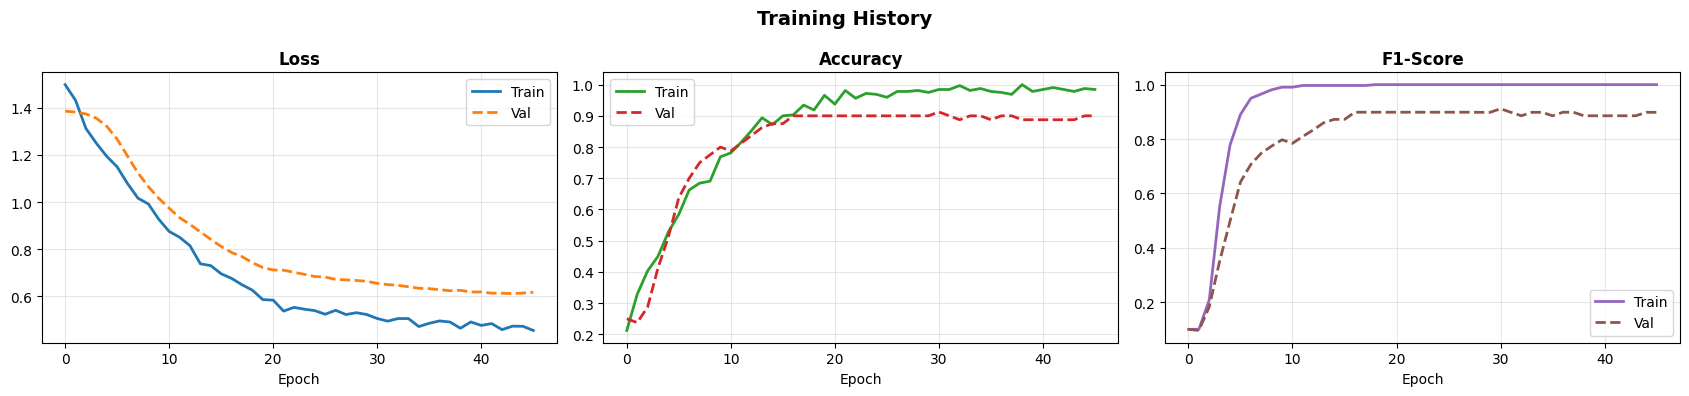

 Saved: training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

metrics = [
    ("loss",    "Loss",     "tab:blue",   "tab:orange"),
    ("acc",     "Accuracy", "tab:green",  "tab:red"),
    ("f1",      "F1-Score", "tab:purple", "tab:brown"),
]
for ax, (key, title, tc, vc) in zip(axes, metrics):
    ax.plot(history[f"train_{key}"], label="Train", color=tc, lw=2)
    ax.plot(history[f"val_{key}"],   label="Val",   color=vc, lw=2, ls="--")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Saved: training_curves.png")


##  Step 8 — Final Evaluation + Confusion Matrix

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Mixed       0.94      0.80      0.86        20
    Negative       0.91      1.00      0.95        20
     Neutral       0.86      0.95      0.90        20
    Positive       0.95      0.90      0.92        20

    accuracy                           0.91        80
   macro avg       0.92      0.91      0.91        80
weighted avg       0.92      0.91      0.91        80

Weighted F1-Score : 0.9113
Accuracy          : 91.25%


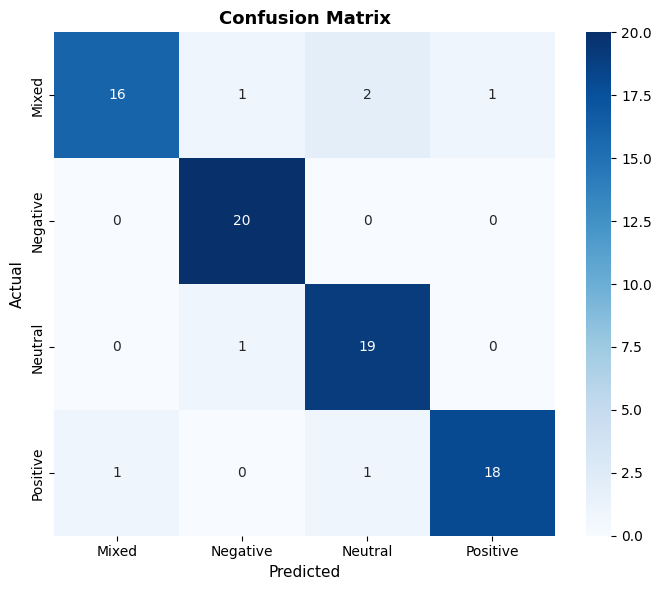

 Saved: confusion_matrix.png


In [ ]:
_, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_dl, criterion, device)

print("=" * 50)
print("       CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(val_labels, val_preds, target_names=encoder.classes_))
print(f"Weighted F1-Score : {val_f1:.4f}")
print(f"Accuracy          : {val_acc:.2%}")

cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_, ax=ax)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual",    fontsize=11)
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Saved: confusion_matrix.png")


##  Step 9 — Save Model

In [ ]:
torch.save({
    "model_state":   best_state,
    "input_dim":     X.shape[1],
    "num_classes":   len(encoder.classes_),
    "label_classes": encoder.classes_.tolist(),
}, "sentiment_model.pth")

print("Model saved: sentiment_model.pth")
print("   Use this file to load the model later without retraining.")


Model saved: sentiment_model.pth
   Use this file to load the model later without retraining.


##  Step 10 — Live Predictions on New Text

In [ ]:
def predict(text):
    model.eval()
    cleaned = preprocessor.preprocess(text)
    tfidf   = vectorizer.transform([cleaned]).toarray().astype(np.float32)
    tensor  = torch.tensor(tfidf, dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    pred_label = encoder.inverse_transform([probs.argmax()])[0]
    confidence = probs.max() * 100
    all_probs  = dict(zip(encoder.classes_, (probs * 100).round(1)))
    return pred_label, confidence, all_probs


test_sentences = [
    "I am incredibly happy with this amazing product!",
    "This is absolutely terrible, I want my money back.",
    "The product is fine, nothing extraordinary.",
    "Great features but the price is too high for the quality.",
    "Delivery was fast but the product broke on the first day.",  # Mixed
    "It arrived on time and works as described.",                  # Neutral
]

print(f"{'─'*62}")
print(f"  {'TEXT':<42} {'LABEL':<10} CONF")
print(f"{'─'*62}")
for s in test_sentences:
    label, conf, probs = predict(s)
    print(f"  {s[:42]:<42} {label:<10} {conf:.1f}%")
    print(f"  {'':42} {' | '.join([f'{k}: {v}%' for k,v in probs.items()])}")
    print()


──────────────────────────────────────────────────────────────
  TEXT                                       LABEL      CONF
──────────────────────────────────────────────────────────────
  I am incredibly happy with this amazing pr Positive   59.5%
                                             Mixed: 19.100000381469727% | Negative: 10.699999809265137% | Neutral: 10.699999809265137% | Positive: 59.5%

  This is absolutely terrible, I want my mon Negative   66.0%
                                             Mixed: 6.300000190734863% | Negative: 66.0% | Neutral: 5.199999809265137% | Positive: 22.5%

  The product is fine, nothing extraordinary Neutral    79.0%
                                             Mixed: 6.0% | Negative: 7.599999904632568% | Neutral: 79.0% | Positive: 7.400000095367432%

  Great features but the price is too high f Mixed      69.0%
                                             Mixed: 69.0% | Negative: 12.899999618530273% | Neutral: 6.699999809265137% | Positive: 11.3

##  Step 11 — Try Your Own Text!

In [ ]:

my_text = "The product looks amazing but stopped working after a week."

label, confidence, all_probs = predict(my_text)

print(f"Input     : {my_text}")
print(f"Predicted : {label}")
print(f"Confidence: {confidence:.1f}%")
print(f"All probs : {all_probs}")


Input     : The product looks amazing but stopped working after a week.
Predicted : Mixed
Confidence: 73.7%
All probs : {'Mixed': np.float32(73.7), 'Negative': np.float32(9.6), 'Neutral': np.float32(5.7), 'Positive': np.float32(11.1)}
